
First 5 Rows
   VIN (1-10)     County          City State  Postal Code  Model Year   Make  \
0  YV4H60PE7S     Kitsap     Bremerton    WA      98310.0        2025  VOLVO   
1  5YJ3E1EB3K  Snohomish      Lynnwood    WA      98087.0        2019  TESLA   
2  1FADP5CUXD     Kitsap  Port Orchard    WA      98367.0        2013   FORD   
3  5YJSA1H20E   Thurston          Yelm    WA      98597.0        2014  TESLA   
4  7SAYGDEE2P  Snohomish       Bothell    WA      98012.0        2023  TESLA   

     Model                   Electric Vehicle Type  \
0     XC90  Plug-in Hybrid Electric Vehicle (PHEV)   
1  MODEL 3          Battery Electric Vehicle (BEV)   
2    C-MAX  Plug-in Hybrid Electric Vehicle (PHEV)   
3  MODEL S          Battery Electric Vehicle (BEV)   
4  MODEL Y          Battery Electric Vehicle (BEV)   

   Clean Alternative Fuel Vehicle (CAFV) Eligibility  Electric Range  \
0            Clean Alternative Fuel Vehicle Eligible            32.0   
1            Clean Alternative Fuel 

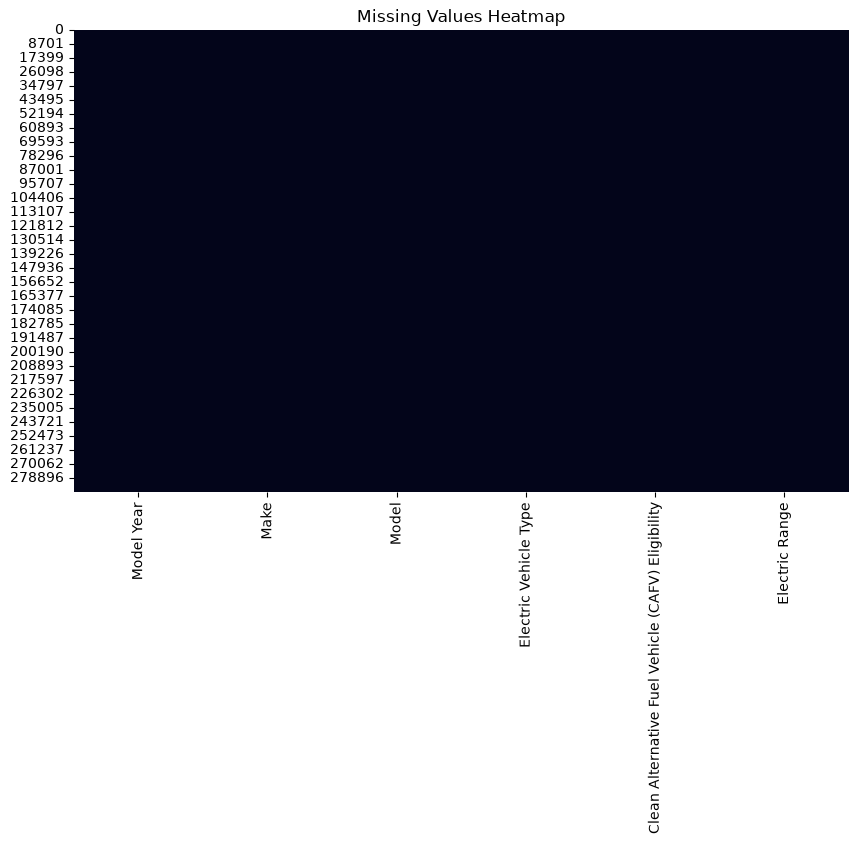

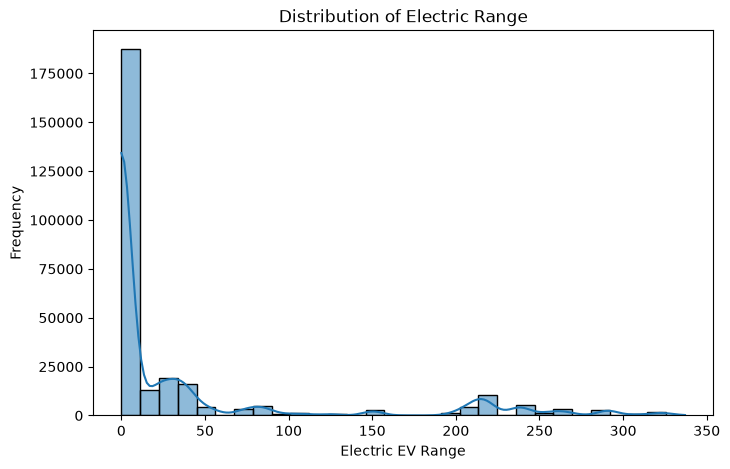

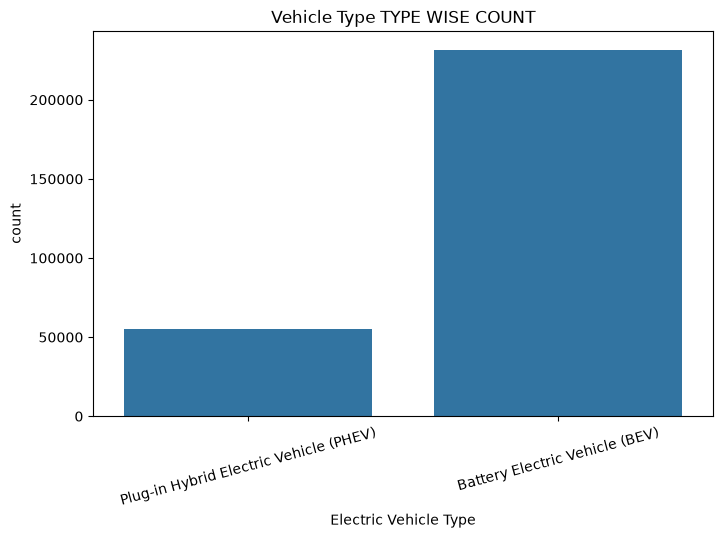

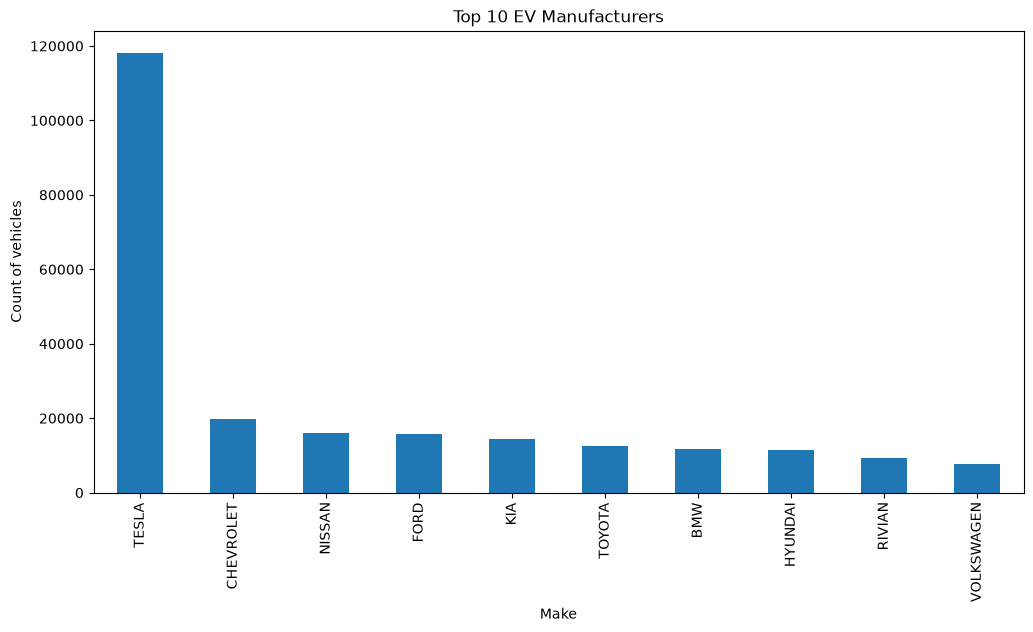

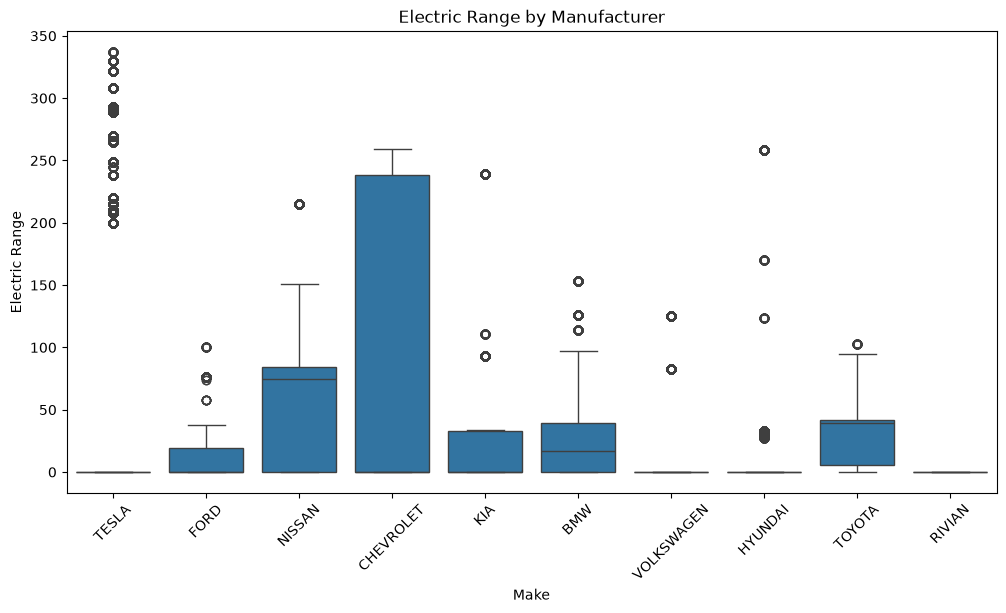


Shape After Encoding
(287007, 246)


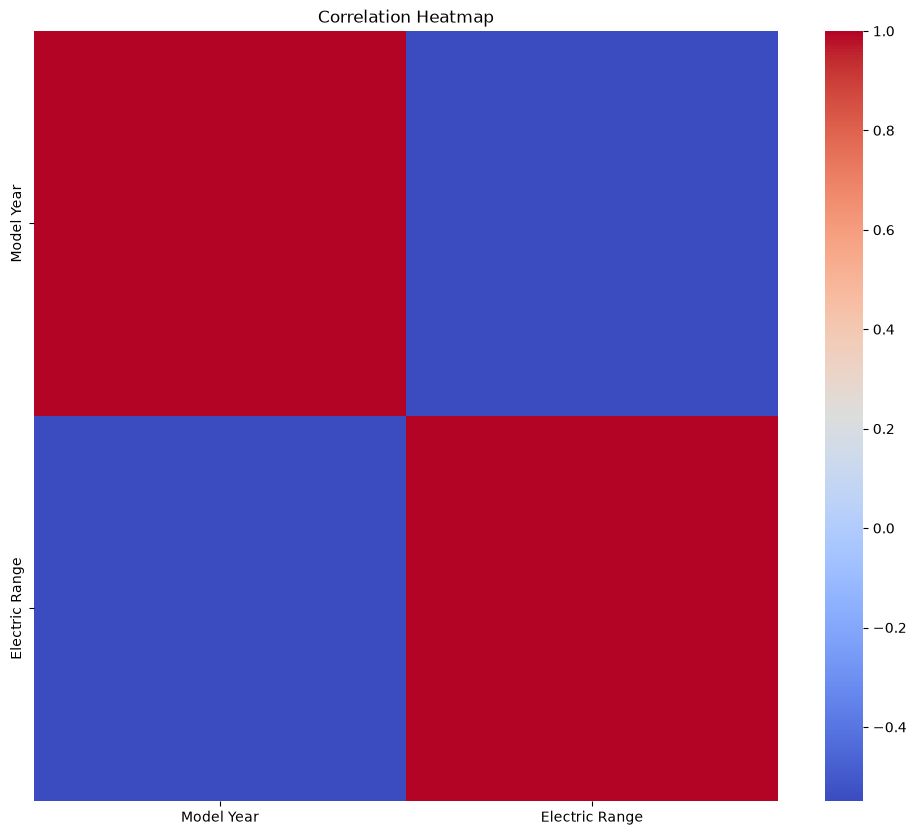


Training Shape
(229605, 245)

Testing Shape
(57402, 245)

LINEAR REGRESSION RESULTS
MAE: 9.615562292631985
MSE: 336.5424537815272
RMSE: 18.345093452515503
R2: 0.9424084563097554

RANDOM FOREST RESULTS
MAE: 0.3825750552790218
MSE: 10.455209545108898
RMSE: 3.233451645704463
R2: 0.9982108300140383

Top 15 Important Features
                                               Feature  Importance
0                                           Model Year    0.641544
242  Electric Vehicle Type_Plug-in Hybrid Electric ...    0.232063
33                                         Make_NISSAN    0.034966
153                                         Model_LEAF    0.028597
243  Clean Alternative Fuel Vehicle (CAFV) Eligibil...    0.024732
41                                          Make_TESLA    0.015544
244  Clean Alternative Fuel Vehicle (CAFV) Eligibil...    0.003735
72                                       Model_BOLT EV    0.002865
138                                           Model_I3    0.001659
45    

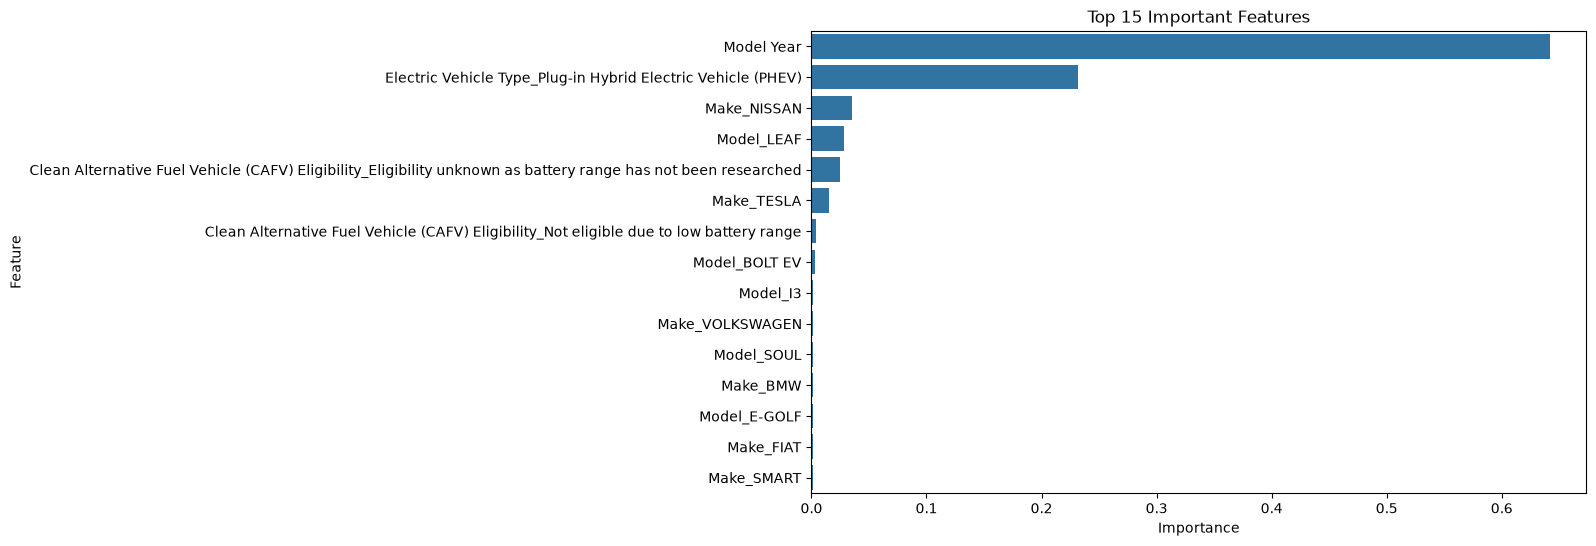


Model Comparison
               Model  R2 Score
0  Linear Regression  0.942408
1      Random Forest  0.998211


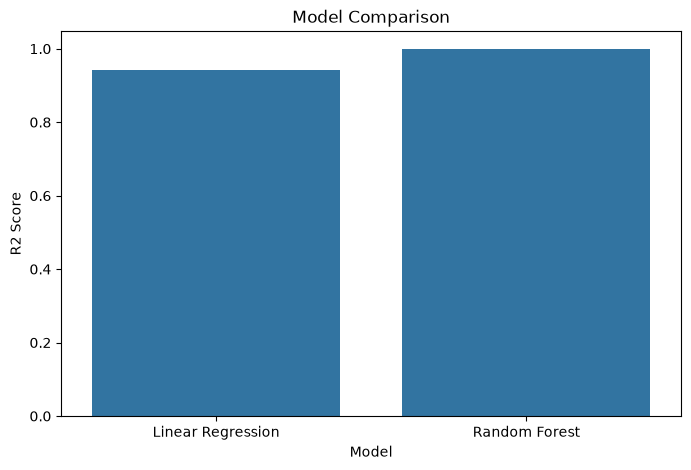


Sample Predictions
    Actual  Predicted
0    215.0      215.0
1      0.0        0.0
2      0.0        0.0
3      0.0        0.0
4     35.0       35.0
5     39.0       39.0
6      0.0        0.0
7     25.0       25.0
8      0.0        0.0
9      0.0        0.0
10   215.0      215.0
11   150.0      150.0
12     0.0        0.0
13     0.0        0.0
14     0.0        0.0
15    14.0       14.0
16   291.0      291.0
17     0.0        0.0
18    32.0       32.0
19    35.0       35.0


In [15]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

# DATA SET 
data_ev = pd.read_csv( r"C:\Users\Hi\OneDrive\Desktop\EV-RANGE-PREDECTOR\data\Electric_Vehicle_Population_Data sample.csv")
print("\nFirst 5 Rows")
print(data_ev.head())
print("\nDataset Info")
print(data_ev.info())

#clean the data
print("\nShape Before Cleaning")
print(data_ev.shape)
print("\nNull Values Before Cleaning")
print(data_ev.isnull().sum())
data_ev = data_ev.dropna()
print("\nNull Values After Cleaning")
print(data_ev.isnull().sum())
print("\nShape After Cleaning")
print(data_ev.shape)

# drop unessary coloums
drop_cols = [
    'VIN (1-10)',
    'DOL Vehicle ID',
    'County',
    'City',
    'State',
    'Postal Code',
    'Legislative District',
    'Vehicle Location',
    'Electric Utility',
    '2020 Census Tract'
]
data_ev = data_ev.drop(columns=drop_cols, errors='ignore')
print("\nRemaining Columns")
print(data_ev.columns)

#VISUALIZATION
# 1. Missing Values Heatmap

plt.figure(figsize=(10,6))
sns.heatmap(data_ev.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

# 2. Histogram of ev range 
plt.figure(figsize=(8,5))
sns.histplot(
    data_ev['Electric Range'],
    bins=30,
    kde=True
)
plt.title("Distribution of Electric Range")
plt.xlabel("Electric EV Range")
plt.ylabel("Frequency")
plt.savefig("../images/range_distribution.png")
plt.show()

# 3. vechile types available (TYPE OF EV)
plt.figure(figsize=(8,5))
sns.countplot(
    data=data_ev,
    x='Electric Vehicle Type'
)

plt.title("Vehicle Type TYPE WISE COUNT")
plt.xticks(rotation=15)
plt.savefig("../images/vehicle_types.png")
plt.show()

# Top Manufacturers 
plt.figure(figsize=(12,6))
data_ev['Make'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 EV Manufacturers")
plt.ylabel("Count of vehicles")
plt.savefig("../images/top_manufacturers.png")
plt.show()

top_makes = data_ev['Make'].value_counts().head(10).index
temp = data_ev[data_ev['Make'].isin(top_makes)]
plt.figure(figsize=(12,6))
sns.boxplot(data=temp,x='Make',y='Electric Range')
plt.xticks(rotation=45)
plt.title("Electric Range by Manufacturer")
plt.savefig("../images/electric_range_by_manufacturer.png")
plt.show()

# ENCODE CATEGORICAL DATA
data_ev = pd.get_dummies( data_ev,drop_first=True)
print("\nShape After Encoding")
print(data_ev.shape)

# Correlation Heatmap
numeric_df = data_ev.select_dtypes(include=np.number)
plt.figure(figsize=(12,10))
sns.heatmap(numeric_df.corr(),cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#  FEATURES AND TARGET , data split 
y = data_ev['Electric Range']
X = data_ev.drop('Electric Range',axis=1)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Shape")
print(X_train.shape)

print("\nTesting Shape")
print(X_test.shape)

# linear regression model
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)

print("\nLINEAR REGRESSION RESULTS")
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
print(
    "MAE:",
    mean_absolute_error(
        y_test,
        lr_pred
    )
)

print(
    "MSE:",
    mean_squared_error(
        y_test,
        lr_pred
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            lr_pred
        )
    )
)

print(
    "R2:",
    r2_score(
        y_test,
        lr_pred
    )
)
# random forest regressor model
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor( n_estimators=100,random_state=42)

rf.fit(  X_train,   y_train)

rf_pred = rf.predict(X_test)

print("\nRANDOM FOREST RESULTS")

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        rf_pred
    )
)

print(
    "MSE:",
    mean_squared_error(
        y_test,
        rf_pred
    )
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            rf_pred
        )
    )
)

print(
    "R2:",
    r2_score(
        y_test,
        rf_pred
    )
)

#  FEATURE IMPORTANCE
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop 15 Important Features")

print(
    importance.head(15)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x='Importance',
    y='Feature')

plt.title(
    "Top 15 Important Features"
)
plt.savefig("../images/feature_importance.png")

plt.show()

#  MODEL COMPARISON
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest'
    ],
    'R2 Score': [
        r2_score(
            y_test,
            lr_pred
        ),
        r2_score(
            y_test,
            rf_pred
        )
    ]
})

print("\nModel Comparison")
print(results)

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x='Model',
    y='R2 Score'
)

plt.title("Model Comparison")
plt.savefig("../images/model_comparison.png")
plt.show()

#  SAMPLE PREDICTION
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': rf_pred
})

print("\nSample Predictions")

print(
    comparison.head(20)
)